In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/wisdomsiddharth/ipl-2026-season-stats-batting-and-bowling/ipl_2026_bowling.csv
/kaggle/input/datasets/wisdomsiddharth/ipl-2026-season-stats-batting-and-bowling/ipl_2026_batting.csv


In [2]:
import pandas as pd
import numpy as np

batting = pd.read_csv('/kaggle/input/datasets/wisdomsiddharth/ipl-2026-season-stats-batting-and-bowling/ipl_2026_batting.csv')
bowling = pd.read_csv('/kaggle/input/datasets/wisdomsiddharth/ipl-2026-season-stats-batting-and-bowling/ipl_2026_bowling.csv')

print("Batting shape:", batting.shape)
print("Bowling shape:", bowling.shape)
batting.head()

Batting shape: (167, 15)
Bowling shape: (104, 14)


,pos,player,team,runs,mat,inns,no,hs,avg,bf,sr,100,50,4s,6s
0,1,Vaibhav Sooryavanshi,RR,776,16,16,0,103,48.50,327,237.30,1,5,63,72
1,2,Shubman Gill,GT,732,16,16,0,104,45.75,449,163.02,1,6,74,33
2,3,Sai Sudharsan,GT,722,17,17,1,100,45.13,457,157.98,1,8,75,30
3,4,Virat Kohli,RCB,675,16,16,4,105*,56.25,407,165.84,1,5,73,25
4,5,Heinrich Klaasen,SRH,624,15,15,2,69,48.00,390,160.00,0,6,48,31


In [3]:
def batting_tier(runs):
    if runs >= 500:
        return 'Elite'
    elif runs >= 300:
        return 'Good'
    else:
        return 'Average'

batting['tier'] = batting['runs'].apply(batting_tier)
print(batting['tier'].value_counts())
batting[['player', 'team', 'runs', 'tier']].head(10)

tier
Average    133
Good        21
Elite       13
Name: count, dtype: int64


,player,team,runs,tier
0,Vaibhav Sooryavanshi,RR,776,Elite
1,Shubman Gill,GT,732,Elite
2,Sai Sudharsan,GT,722,Elite
3,Virat Kohli,RCB,675,Elite
4,Heinrich Klaasen,SRH,624,Elite
5,Ishan Kishan,SRH,602,Elite
6,KL Rahul,DC,593,Elite
7,Abhishek Sharma,SRH,563,Elite
8,Mitchell Marsh,LSG,563,Elite
9,Jos Buttler,GT,526,Elite


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

features = ['runs', 'mat', 'inns', 'avg', 'sr', '4s', '6s', '50', '100']
X = batting[features]
y = batting['tier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Average       1.00      1.00      1.00        24
       Elite       1.00      0.50      0.67         2
        Good       0.89      1.00      0.94         8

    accuracy                           0.97        34
   macro avg       0.96      0.83      0.87        34
weighted avg       0.97      0.97      0.97        34



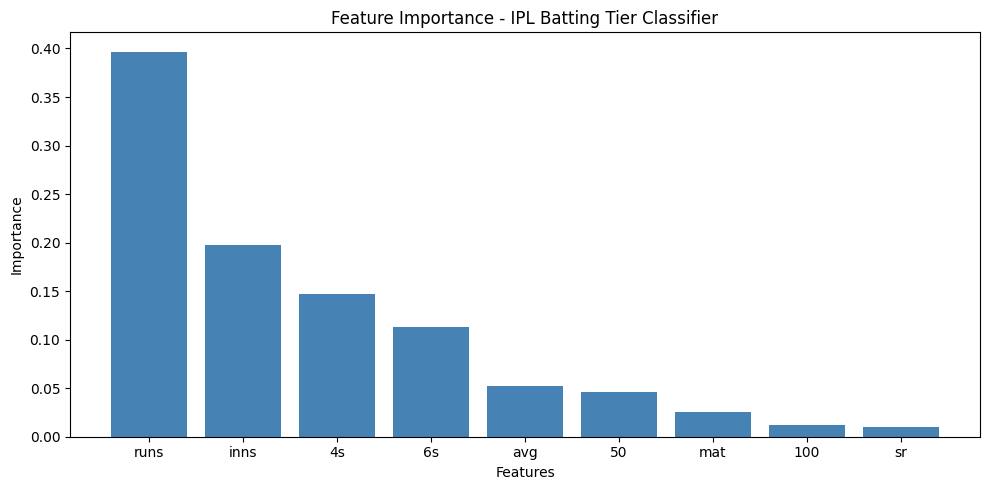

  feature  importance
0    runs    0.396807
2    inns    0.197248
5      4s    0.147063
6      6s    0.113010
3     avg    0.052096
7      50    0.046116
1     mat    0.025934
8     100    0.011688
4      sr    0.010039


In [5]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(importance['feature'], importance['importance'], color='steelblue')
plt.title('Feature Importance - IPL Batting Tier Classifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(importance)

In [6]:
def predict_player_tier(player_name):
    player = batting[batting['player'].str.contains(player_name, case=False)]
    if player.empty:
        print("Player not found")
        return
    X_player = player[features]
    tier = model.predict(X_player)[0]
    proba = model.predict_proba(X_player)[0]
    classes = model.classes_
    print(f"Player: {player['player'].values[0]}")
    print(f"Team: {player['team'].values[0]}")
    print(f"Runs: {player['runs'].values[0]}")
    print(f"Predicted Tier: {tier}")
    print("\nConfidence:")
    for c, p in zip(classes, proba):
        print(f"  {c}: {p*100:.1f}%")

predict_player_tier("Kohli")

Player: Virat Kohli
Team: RCB
Runs: 675
Predicted Tier: Elite

Confidence:
  Average: 0.0%
  Elite: 96.0%
  Good: 4.0%


In [7]:
batting['predicted_tier'] = model.predict(batting[features])

print("=== ELITE PLAYERS ===")
print(batting[batting['predicted_tier']=='Elite'][['player','team','runs','avg','sr']].to_string(index=False))

print("\n=== GOOD PLAYERS ===")
print(batting[batting['predicted_tier']=='Good'][['player','team','runs','avg','sr']].to_string(index=False))

=== ELITE PLAYERS ===
              player team  runs   avg     sr
Vaibhav Sooryavanshi   RR   776 48.50 237.30
        Shubman Gill   GT   732 45.75 163.02
       Sai Sudharsan   GT   722 45.13 157.98
         Virat Kohli  RCB   675 56.25 165.84
    Heinrich Klaasen  SRH   624 48.00 160.00
        Ishan Kishan  SRH   602 40.13 182.42
            KL Rahul   DC   593 45.62 174.41
     Abhishek Sharma  SRH   563 40.21 204.72
      Mitchell Marsh  LSG   563 43.31 163.18
         Jos Buttler   GT   526 37.57 152.48
         Dhruv Jurel   RR   515 36.79 154.65
   Prabhsimran Singh PBKS   510 42.50 168.87

=== GOOD PLAYERS ===
              player team  runs   avg     sr
       Rajat Patidar  RCB   501 41.75 192.69
        Shreyas Iyer PBKS   498 55.33 168.81
     Cooper Connolly PBKS   491 44.64 163.12
        Sanju Samson  CSK   477 43.36 165.62
    Devdutt Padikkal  RCB   464 33.14 168.72
      Ryan Rickelton   MI   448 40.73 186.66
    Yashasvi Jaiswal   RR   427 30.50 152.50
Angkrish Ra

In [8]:
def bowling_tier(wkts):
    if wkts >= 20:
        return 'Elite'
    elif wkts >= 12:
        return 'Good'
    else:
        return 'Average'

bowling['tier'] = bowling['wkts'].apply(bowling_tier)
print(bowling['tier'].value_counts())

tier
Average    76
Good       22
Elite       6
Name: count, dtype: int64


In [9]:
bowling_features = ['wkts', 'mat', 'inns', 'avg', 'econ', 'sr', '4w', '5w']
X_bowl = bowling[bowling_features]
y_bowl = bowling['tier']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bowl, y_bowl, test_size=0.2, random_state=42)

bowl_model = RandomForestClassifier(n_estimators=100, random_state=42)
bowl_model.fit(X_train_b, y_train_b)

y_pred_b = bowl_model.predict(X_test_b)
print(classification_report(y_test_b, y_pred_b))

              precision    recall  f1-score   support

     Average       1.00      1.00      1.00        15
       Elite       1.00      0.50      0.67         2
        Good       0.80      1.00      0.89         4

    accuracy                           0.95        21
   macro avg       0.93      0.83      0.85        21
weighted avg       0.96      0.95      0.95        21



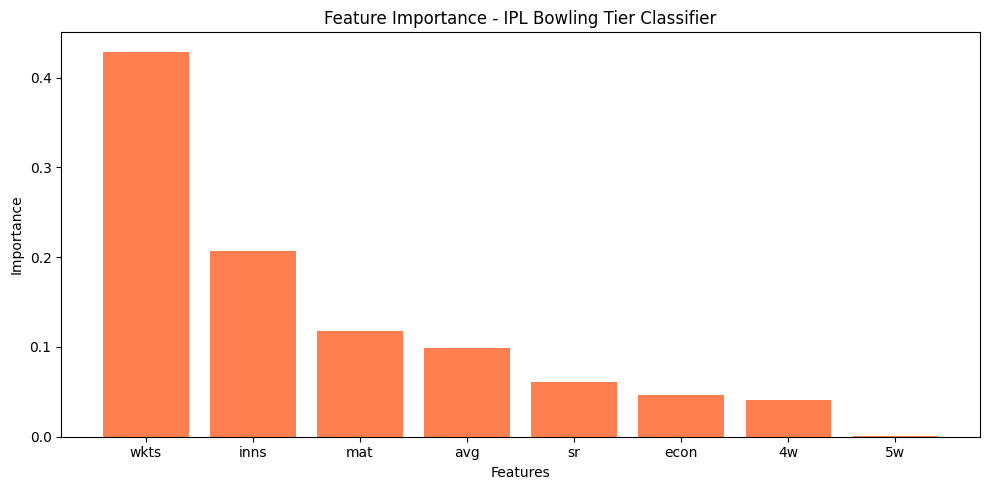

  feature  importance
0    wkts    0.428868
2    inns    0.206343
1     mat    0.117406
3     avg    0.098584
5      sr    0.060775
4    econ    0.046610
6      4w    0.040884
7      5w    0.000530


In [10]:
importance_bowl = pd.DataFrame({
    'feature': bowling_features,
    'importance': bowl_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(importance_bowl['feature'], importance_bowl['importance'], color='coral')
plt.title('Feature Importance - IPL Bowling Tier Classifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(importance_bowl)

In [11]:
def predict_bowler_tier(player_name):
    player = bowling[bowling['player'].str.contains(player_name, case=False)]
    if player.empty:
        print("Player not found")
        return
    X_player = player[bowling_features]
    tier = bowl_model.predict(X_player)[0]
    proba = bowl_model.predict_proba(X_player)[0]
    classes = bowl_model.classes_
    print(f"Player: {player['player'].values[0]}")
    print(f"Team: {player['team'].values[0]}")
    print(f"Wickets: {player['wkts'].values[0]}")
    print(f"Predicted Tier: {tier}")
    print("\nConfidence:")
    for c, p in zip(classes, proba):
        print(f"  {c}: {p*100:.1f}%")

predict_bowler_tier("Rabada")

Player: Kagiso Rabada
Team: GT
Wickets: 29
Predicted Tier: Elite

Confidence:
  Average: 2.0%
  Elite: 74.0%
  Good: 24.0%


In [12]:
bowling['predicted_tier'] = bowl_model.predict(bowling[bowling_features])
print("=== ELITE BOWLERS ===")
print(bowling[bowling['predicted_tier']=='Elite'][['player','team','wkts','avg','econ']].to_string(index=False))

print("\n=== GOOD BOWLERS ===")
print(bowling[bowling['predicted_tier']=='Good'][['player','team','wkts','avg','econ']].to_string(index=False))

=== ELITE BOWLERS ===
           player team  wkts   avg  econ
    Kagiso Rabada   GT    29 21.58  9.68
Bhuvneshwar Kumar  RCB    28 17.89  7.95
     Jofra Archer   RR    25 22.36  9.31
      Rashid Khan   GT    21 24.57  9.07
    Eshan Malinga  SRH    20 25.35  9.33

=== GOOD BOWLERS ===
          player team  wkts   avg  econ
   Anshul Kamboj  CSK    21 25.23 10.52
  Mohammed Siraj   GT    19 29.57  9.06
      Rasikh Dar  RCB    19 21.31  9.45
    Kartik Tyagi  KKR    18 27.66  9.76
    Jason Holder   GT    17 17.05  7.58
    Prince Yadav  LSG    16 28.68  8.82
 Prasidh Krishna   GT    16 25.43 10.43
    Sunil Narine  KKR    15 22.60  6.64
   Sakib Hussain  SRH    15 26.46  9.45
  Josh Hazlewood  RCB    15 32.93  9.59
    AM Ghazanfar   MI    15 25.93 10.01
   Krunal Pandya  RCB    14 30.35  8.41
   Jamie Overton  CSK    14 17.78  8.89
  Brijesh Sharma   RR    14 32.14  9.89
   Nandre Burger   RR    14 31.42 10.11
  Arshdeep Singh PBKS    14 38.64 10.20
    Praful Hinge  SRH    14 21

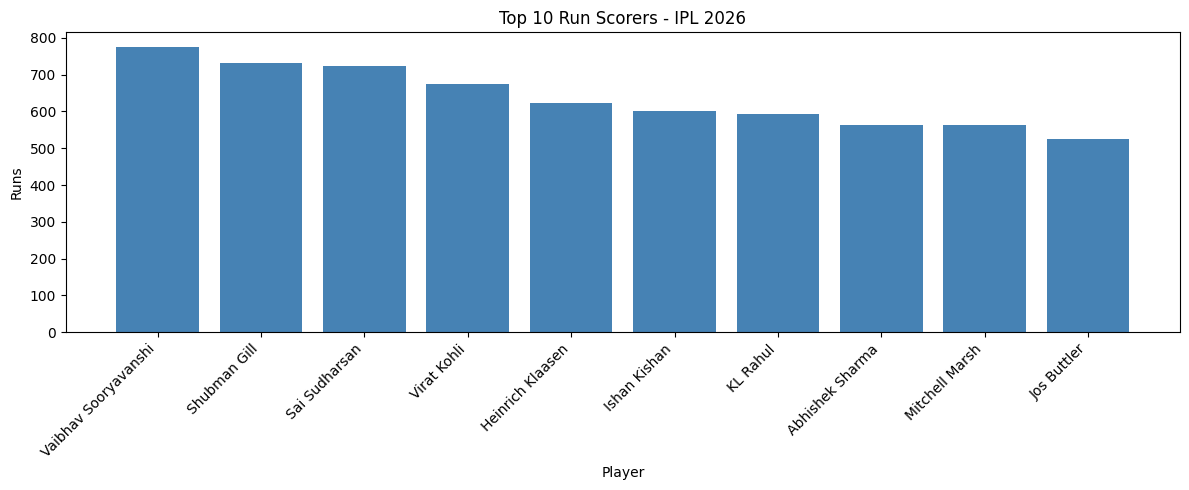

In [13]:
plt.figure(figsize=(12, 5))
top10_bat = batting.nlargest(10, 'runs')
plt.bar(top10_bat['player'], top10_bat['runs'], color='steelblue')
plt.title('Top 10 Run Scorers - IPL 2026')
plt.xlabel('Player')
plt.ylabel('Runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

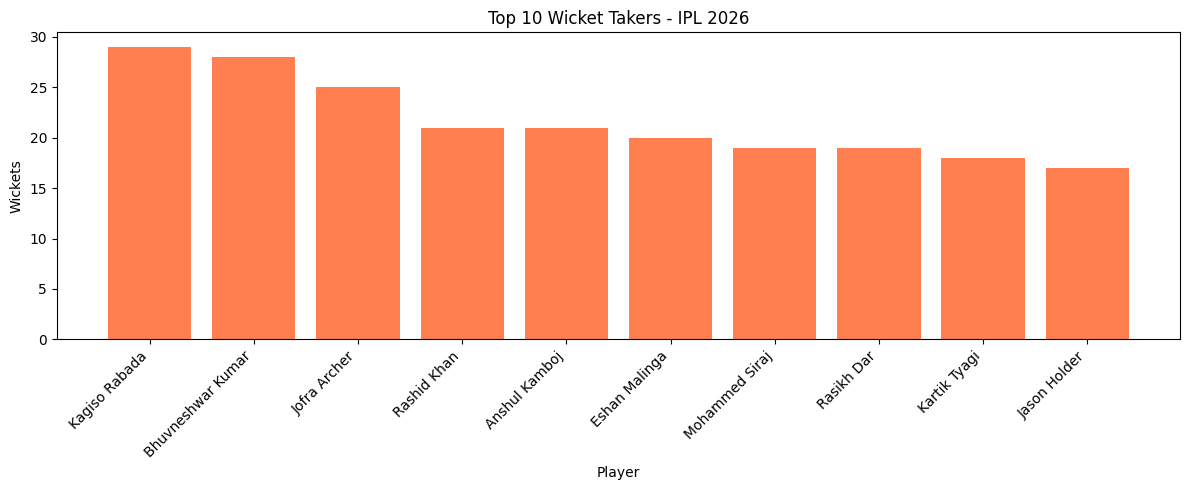

In [14]:
plt.figure(figsize=(12, 5))
top10_bowl = bowling.nlargest(10, 'wkts')
plt.bar(top10_bowl['player'], top10_bowl['wkts'], color='coral')
plt.title('Top 10 Wicket Takers - IPL 2026')
plt.xlabel('Player')
plt.ylabel('Wickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

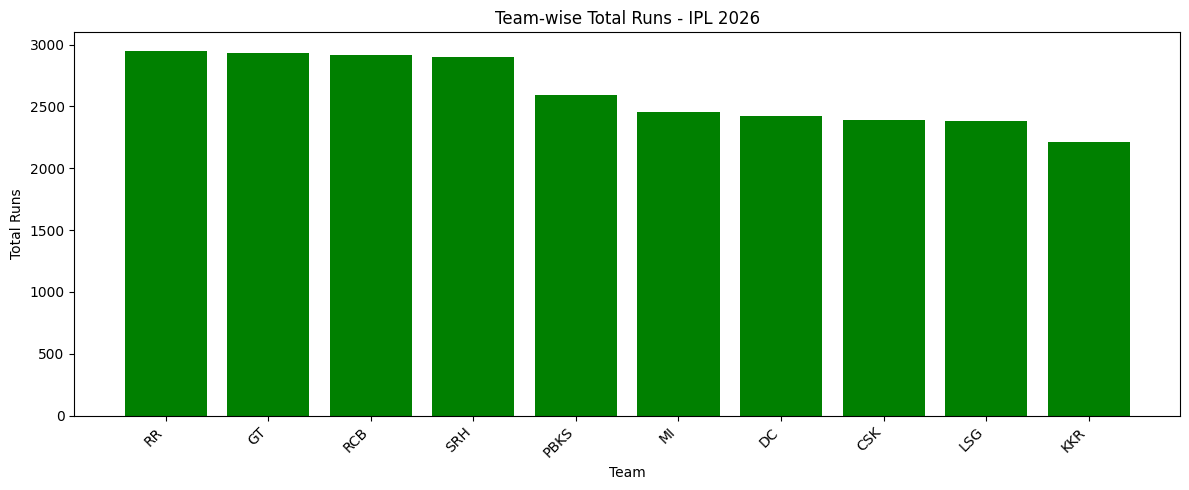

In [15]:
team_runs = batting.groupby('team')['runs'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(team_runs.index, team_runs.values, color='green')
plt.title('Team-wise Total Runs - IPL 2026')
plt.xlabel('Team')
plt.ylabel('Total Runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
common = pd.merge(batting[['player', 'team', 'runs', 'avg', 'sr']], 
                  bowling[['player', 'wkts', 'econ']], on='player')

common['allrounder_score'] = (common['runs'] / common['runs'].max() * 50) + \
                              (common['wkts'] / common['wkts'].max() * 50)

common = common.sort_values('allrounder_score', ascending=False)
print("=== TOP ALL-ROUNDERS ===")
print(common[['player', 'team', 'runs', 'wkts', 'allrounder_score']].head(10).to_string(index=False))

=== TOP ALL-ROUNDERS ===
            player team  runs  wkts  allrounder_score
     Kagiso Rabada   GT    47    29         55.731707
 Bhuvneshwar Kumar  RCB    34    28         52.422204
       Travis Head  SRH   410     1         51.724138
     Krunal Pandya  RCB   226    14         51.698907
     Cameron Green  KKR   322     7         51.337258
      Jofra Archer   RR    64    25         50.908326
Nitish Kumar Reddy  SRH   302     8         50.622372
   Ravindra Jadeja   RR   266    10         49.680404
 Washington Sundar   GT   377     1         47.699748
     Anshul Kamboj  CSK    58    21         43.280067
